In [21]:
import openeo
import xarray
import matplotlib.pyplot as plt

In [22]:
connection = openeo.connect(url="openeo.dataspace.copernicus.eu")
connection.authenticate_oidc()
# Your client credentials
# client_id = 'sh-01c17c5d-5c71-4472-a5c7-4e581e987184'
# client_secret = '49or660aaYniF4cUBm8cehGKFk5GRYxN'

Authenticated using refresh token.


<Connection to 'https://openeo.dataspace.copernicus.eu/openeo/1.2/' with OidcBearerAuth>

In [59]:
#seems to deliver 10m resolution, regardless of band
s2_cube = connection.load_collection(
    "SENTINEL2_L2A",
    temporal_extent=("2022-05-01", "2022-05-03"),
    spatial_extent={
        "west": -119.10,
        "south": 37.59,
        "east": -118.95,
        "north": 37.67,    
    },
    bands=["B12", "B11", "B8A", "B08", "B07","B06","B05","B04", "B03", "B02","B01"],
    max_cloud_cover=50,
)


In [60]:
s2_cube.download("load-raw.nc")

In [61]:
ds = xarray.load_dataset("load-raw.nc")

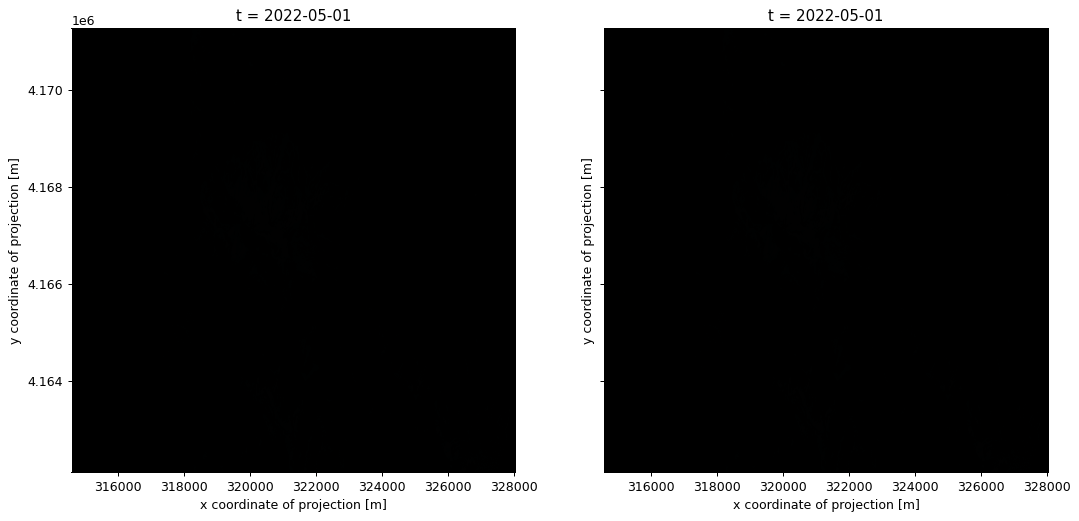

In [74]:
# Convert xarray DataSet to a (bands, t, x, y) DataArray
data = ds[["B07", "B03", "B02"]].to_array(dim="bands")

fig, axes = plt.subplots(ncols=2, figsize=(14, 16), dpi=90, sharey=True)
axes[0].set_box_aspect(1)
axes[1].set_box_aspect(1)
data[{"t": 0}].plot.imshow(vmin=0, vmax=2000, ax=axes[0])
data[{"t": -1}].plot.imshow(vmin=0, vmax=2000, ax=axes[1])

In [75]:
data

<xarray.DataArray (bands: 3, t: 1, y: 917, x: 1344)>
array([[[[3.7640002 , 3.163     , 3.163     , ..., 1.5810001 ,
          1.5810001 , 1.493     ],
         [3.7640002 , 3.163     , 3.163     , ..., 1.5810001 ,
          1.5810001 , 1.493     ],
         [3.8550003 , 3.8680003 , 3.8680003 , ..., 1.6680001 ,
          1.6680001 , 1.7080001 ],
         ...,
         [2.8820002 , 3.0260003 , 3.0260003 , ..., 2.9180002 ,
          2.9180002 , 2.049     ],
         [2.8820002 , 3.0260003 , 3.0260003 , ..., 2.9180002 ,
          2.9180002 , 2.049     ],
         [2.8230002 , 2.7400002 , 2.7400002 , ..., 2.6020002 ,
          2.6020002 , 2.446     ]]],


       [[[2.4780002 , 2.15      , 2.036     , ..., 0.596     ,
          0.50100005, 0.462     ],
         [2.5540001 , 1.7160001 , 2.174     , ..., 0.45100003,
          0.48000002, 0.40100002],
         [3.6880002 , 2.732     , 3.3520002 , ..., 0.39100003,
...
          2.262     , 1.8960001 ],
         [1.636     , 1.552     , 1.4720001 , ..., 2.3760002 ,
          2.578     , 1.021     ],
         [1.194     , 1.192     , 1.3520001 , ..., 2.4080002 ,
          1.9240001 , 1.222     ]]],


       [[[1.932     , 1.644     , 1.4540001 , ..., 0.508     ,
          0.34500003, 0.29700002],
         [2.676     , 1.36      , 2.476     , ..., 0.26200002,
          0.328     , 0.23700002],
         [3.5080001 , 2.624     , 3.0080001 , ..., 0.254     ,
          0.321     , 0.21200001],
         ...,
         [1.7360001 , 1.766     , 1.062     , ..., 1.6940001 ,
          2.0640001 , 1.5560001 ],
         [1.34      , 1.182     , 1.028     , ..., 2.148     ,
          2.374     , 0.78900003],
         [0.808     , 0.76400006, 1.0660001 , ..., 2.276     ,
          1.748     , 1.0020001 ]]]], dtype=float32)
Coordinates:
  * t        (t) datetime64[ns] 2022-05-01
  * x        (x) float64 3.146e+05 3.146e+05 3.146e+05 ... 3.28e+05 3.28e+05
  * y        (y) float64 4.171e+06 4.171e+06 4.171e+06 ... 4.162e+06 4.162e+06
  * bands    (bands) object 'B07' 'B03' 'B02'